<a href="https://colab.research.google.com/github/Fu-Pei-Yin/Deep-Generative-Mode/blob/week5/%E3%80%8C%E4%BD%BF%E7%94%A8_Seq2Seq%E7%94%9F%E6%88%90%E3%80%8C%E6%9C%AA%E4%BE%86%E5%AD%B8%E7%BF%92%E8%A1%8C%E7%82%BA%E5%BA%8F%E5%88%97%E3%80%8D%E6%95%B8%E6%93%9A_ipynb%E3%80%8D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
資料載入完成
studentInfo shape: (32593, 12)
studentVle shape: (10655280, 6)
studentAssessment shape: (173912, 5)

處理後資料 shape: (596343, 8)

序列數據 shape: X=(472747, 4, 4), y=(472747, 2)
Train: 332010, Valid: 70348, Test: 70389

========== 訓練 Seq2Seq LSTM ==========
Epoch 1/10, Train Loss: 10784.5650, Valid Loss: 9510.3022
Epoch 2/10, Train Loss: 8841.4097, Valid Loss: 8794.4101
Epoch 3/10, Train Loss: 8471.4648, Valid Loss: 8496.3439
Epoch 4/10, Train Loss: 8331.2702, Valid Loss: 8390.2548
Epoch 5/10, Train Loss: 8261.9983, Valid Loss: 8355.8031
Epoch 6/10, Train Loss: 8211.1029, Valid Loss: 8318.4000
Epoch 7/10, Train Loss: 8190.1097, Valid Loss: 8253.4873
Epoch 8/10, Train Loss: 8172.2798, Valid Loss: 8231.3118
Epoch 9/10, Train Loss: 8167.0897, Valid Loss: 8235.1282
Epoch 10/10, Train Loss: 8149.0062, Valid Loss: 8224.9071

========== 訓練 Seq2Seq VAE ==========
Epo

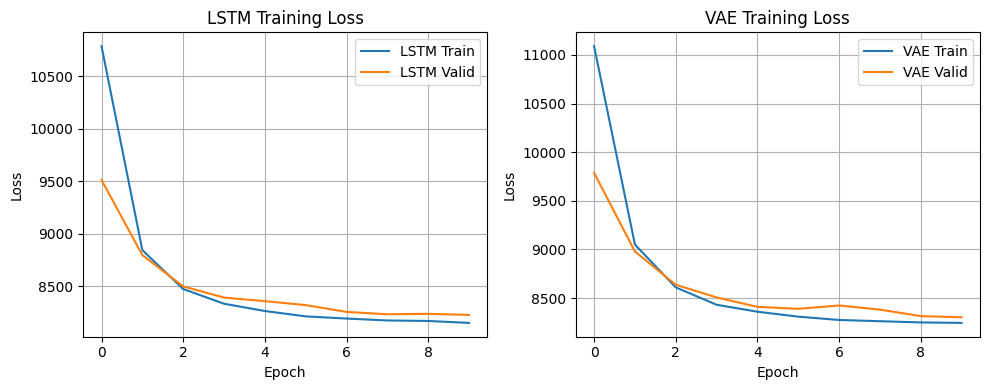

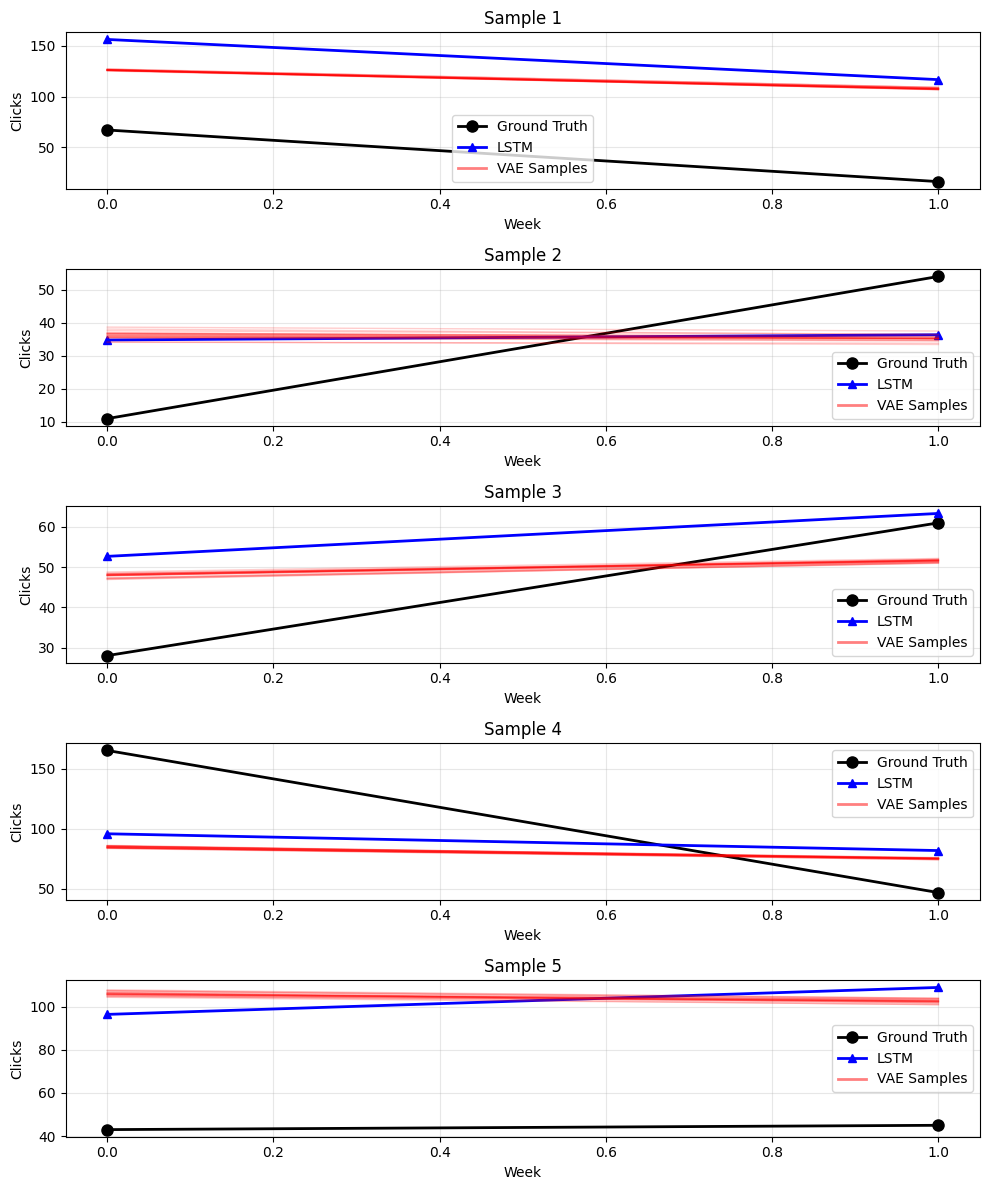

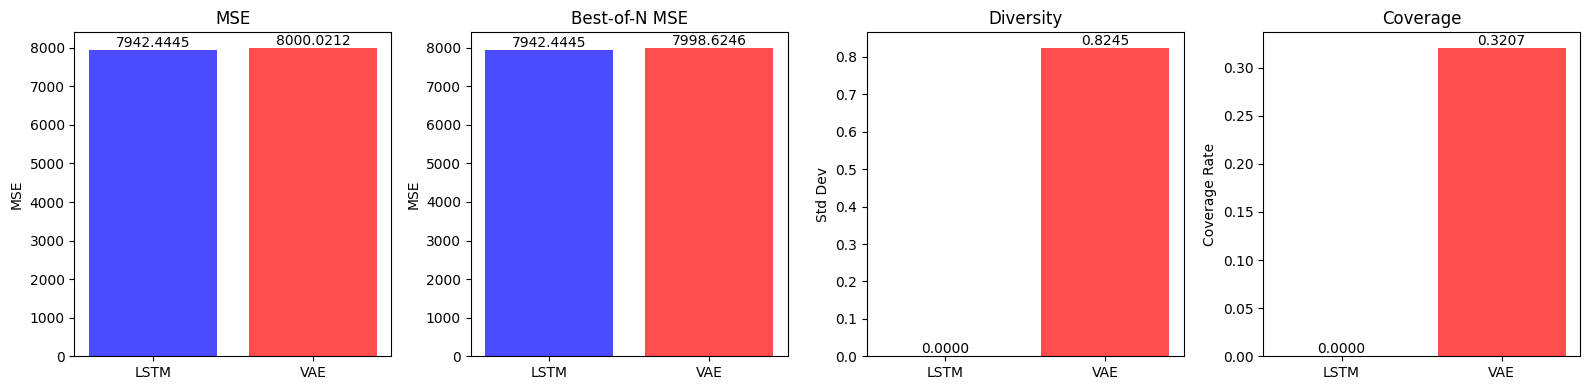


========== 完成！三張圖片已生成 ==========
1. training_loss.png - 訓練損失曲線
2. prediction_comparison.png - 預測結果比較
3. metrics_comparison.png - 評估指標比較


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 設定隨機種子
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==================== 資料讀取與前處理 ====================
# 請修改路徑為您的 Google Drive 中的資料集位置
DATA_PATH = '/content/drive/MyDrive/colab/'  # 修改此路徑

studentInfo = pd.read_csv(DATA_PATH + 'studentInfo.csv')
studentVle = pd.read_csv(DATA_PATH + 'studentVle.csv')
studentAssessment = pd.read_csv(DATA_PATH + 'studentAssessment.csv')

print("資料載入完成")
print(f"studentInfo shape: {studentInfo.shape}")
print(f"studentVle shape: {studentVle.shape}")
print(f"studentAssessment shape: {studentAssessment.shape}")

# 合併資料
# 計算每週點擊數
studentVle['week'] = studentVle['date'] // 7
weekly_clicks = studentVle.groupby(['id_student', 'week'])['sum_click'].sum().reset_index()
weekly_clicks.columns = ['id_student', 'week', 'clicks']

# 計算每週作業提交與分數
studentAssessment_merged = studentAssessment.merge(
    studentInfo[['id_student', 'code_module', 'code_presentation']],
    on='id_student'
)
studentAssessment_merged['week'] = studentAssessment_merged['date_submitted'] // 7
weekly_submit = studentAssessment_merged.groupby(['id_student', 'week']).agg({
    'score': 'mean',
    'id_assessment': 'count'
}).reset_index()
weekly_submit.columns = ['id_student', 'week', 'avg_score', 'submit_cnt']

# 合併特徵
weekly_data = weekly_clicks.merge(weekly_submit, on=['id_student', 'week'], how='outer')
weekly_data = weekly_data.fillna(0)
weekly_data['has_submit'] = (weekly_data['submit_cnt'] > 0).astype(int)

# 計算累積平均分數
weekly_data = weekly_data.sort_values(['id_student', 'week'])
weekly_data['avg_score_sofar'] = weekly_data.groupby('id_student')['avg_score'].expanding().mean().reset_index(level=0, drop=True)
weekly_data['avg_score_sofar'] = weekly_data['avg_score_sofar'].fillna(0)

# 計算點擊數差分
weekly_data['clicks_diff1'] = weekly_data.groupby('id_student')['clicks'].diff().fillna(0)

print(f"\n處理後資料 shape: {weekly_data.shape}")

# ==================== 建立序列資料 ====================
INPUT_WEEKS = 4
OUTPUT_WEEKS = 2
FEATURES = ['clicks', 'has_submit', 'avg_score_sofar', 'clicks_diff1']

def create_sequences(data, input_weeks=4, output_weeks=2):
    sequences = []
    targets = []
    student_ids = []

    for student_id in data['id_student'].unique():
        student_data = data[data['id_student'] == student_id].sort_values('week')

        if len(student_data) < input_weeks + output_weeks:
            continue

        for i in range(len(student_data) - input_weeks - output_weeks + 1):
            input_seq = student_data.iloc[i:i+input_weeks][FEATURES].values
            target_seq = student_data.iloc[i+input_weeks:i+input_weeks+output_weeks]['clicks'].values

            sequences.append(input_seq)
            targets.append(target_seq)
            student_ids.append(student_id)

    return np.array(sequences), np.array(targets), np.array(student_ids)

X, y, student_ids = create_sequences(weekly_data, INPUT_WEEKS, OUTPUT_WEEKS)
print(f"\n序列數據 shape: X={X.shape}, y={y.shape}")

# 以學生 ID 分割資料
unique_students = np.unique(student_ids)
train_students, temp_students = train_test_split(unique_students, test_size=0.3, random_state=SEED)
valid_students, test_students = train_test_split(temp_students, test_size=0.5, random_state=SEED)

train_mask = np.isin(student_ids, train_students)
valid_mask = np.isin(student_ids, valid_students)
test_mask = np.isin(student_ids, test_students)

X_train, y_train = X[train_mask], y[train_mask]
X_valid, y_valid = X[valid_mask], y[valid_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train: {len(X_train)}, Valid: {len(X_valid)}, Test: {len(X_test)}")

# ==================== Dataset ====================
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SequenceDataset(X_train, y_train)
valid_dataset = SequenceDataset(X_valid, y_valid)
test_dataset = SequenceDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ==================== Seq2Seq LSTM 模型 ====================
class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_weeks):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(1, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.output_weeks = output_weeks

    def forward(self, x):
        _, (h, c) = self.encoder(x)

        decoder_input = torch.zeros(x.size(0), self.output_weeks, 1).to(x.device)
        decoder_output, _ = self.decoder(decoder_input, (h, c))

        output = self.fc(decoder_output).squeeze(-1)
        return output

# ==================== Seq2Seq VAE 模型 ====================
class Seq2SeqVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, output_weeks):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.output_weeks = output_weeks

        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc_z = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(1, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, 1)

    def encode(self, x):
        _, (h, _) = self.encoder(x)
        h = h.squeeze(0)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_z(z).unsqueeze(0)
        c = torch.zeros_like(h)

        decoder_input = torch.zeros(z.size(0), self.output_weeks, 1).to(z.device)
        decoder_output, _ = self.decoder(decoder_input, (h, c))

        output = self.fc_out(decoder_output).squeeze(-1)
        return output

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

# ==================== 訓練函數 ====================
def train_lstm(model, train_loader, valid_loader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                valid_loss += loss.item()

        valid_loss /= len(valid_loader)
        valid_losses.append(valid_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")

    return train_losses, valid_losses

def train_vae(model, train_loader, valid_loader, epochs=10, beta=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    mse_criterion = nn.MSELoss()

    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            recon, mu, logvar = model(X_batch)

            recon_loss = mse_criterion(recon, y_batch)
            kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / X_batch.size(0)
            loss = recon_loss + beta * kld_loss

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                recon, mu, logvar = model(X_batch)

                recon_loss = mse_criterion(recon, y_batch)
                kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / X_batch.size(0)
                loss = recon_loss + beta * kld_loss

                valid_loss += loss.item()

        valid_loss /= len(valid_loader)
        valid_losses.append(valid_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")

    return train_losses, valid_losses

# ==================== 訓練模型 ====================
print("\n========== 訓練 Seq2Seq LSTM ==========")
lstm_model = Seq2SeqLSTM(input_dim=len(FEATURES), hidden_dim=64, output_weeks=OUTPUT_WEEKS).to(device)
lstm_train_losses, lstm_valid_losses = train_lstm(lstm_model, train_loader, valid_loader, epochs=10)

print("\n========== 訓練 Seq2Seq VAE ==========")
vae_model = Seq2SeqVAE(input_dim=len(FEATURES), hidden_dim=64, latent_dim=16, output_weeks=OUTPUT_WEEKS).to(device)
vae_train_losses, vae_valid_losses = train_vae(vae_model, train_loader, valid_loader, epochs=10, beta=0.1)

# ==================== 評估與可視化 ====================
def evaluate_lstm(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_test).to(device)
        predictions = model(X_tensor).cpu().numpy()

    mse = np.mean((predictions - y_test) ** 2)
    return predictions, mse

def evaluate_vae(model, X_test, y_test, n_samples=20):
    model.eval()
    all_samples = []

    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_test).to(device)

        for _ in range(n_samples):
            mu, logvar = model.encode(X_tensor)
            z = model.reparameterize(mu, logvar)
            sample = model.decode(z).cpu().numpy()
            all_samples.append(sample)

    all_samples = np.array(all_samples)

    # Best-of-N MSE
    best_mse = np.min([np.mean((sample - y_test) ** 2) for sample in all_samples])

    # Diversity
    diversity = np.mean(np.std(all_samples, axis=0))

    # Coverage
    coverage = np.mean([
        np.any(np.abs(all_samples[:, i] - y_test[i]) < np.std(y_test[i]) * 0.5)
        for i in range(len(y_test))
    ])

    return all_samples, best_mse, diversity, coverage

# 評估
lstm_pred, lstm_mse = evaluate_lstm(lstm_model, X_test, y_test)
vae_samples, vae_best_mse, vae_diversity, vae_coverage = evaluate_vae(vae_model, X_test, y_test, n_samples=20)

print(f"\n========== 評估結果 ==========")
print(f"LSTM MSE: {lstm_mse:.4f}")
print(f"VAE Best-of-N MSE: {vae_best_mse:.4f}")
print(f"VAE Diversity: {vae_diversity:.4f}")
print(f"VAE Coverage: {vae_coverage:.4f}")

# ==================== 圖1: 訓練損失曲線 ====================
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(lstm_train_losses, label='LSTM Train')
plt.plot(lstm_valid_losses, label='LSTM Valid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(vae_train_losses, label='VAE Train')
plt.plot(vae_valid_losses, label='VAE Valid')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 圖2: 預測結果比較 ====================
sample_indices = np.random.choice(len(X_test), 5, replace=False)

fig, axes = plt.subplots(5, 1, figsize=(10, 12))

for idx, sample_idx in enumerate(sample_indices):
    ax = axes[idx]

    # Ground Truth
    ax.plot(range(OUTPUT_WEEKS), y_test[sample_idx], 'ko-', label='Ground Truth', linewidth=2, markersize=8)

    # LSTM 單一路徑
    ax.plot(range(OUTPUT_WEEKS), lstm_pred[sample_idx], 'b^-', label='LSTM', linewidth=2, markersize=6)

    # VAE 多條樣本
    for i in range(vae_samples.shape[0]):
        ax.plot(range(OUTPUT_WEEKS), vae_samples[i, sample_idx], 'r-', alpha=0.2, linewidth=1)

    ax.plot([], [], 'r-', alpha=0.5, label='VAE Samples', linewidth=2)

    ax.set_xlabel('Week')
    ax.set_ylabel('Clicks')
    ax.set_title(f'Sample {idx+1}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 圖3: 評估指標比較 ====================
metrics = ['MSE', 'Best-of-N MSE', 'Diversity', 'Coverage']
lstm_values = [lstm_mse, lstm_mse, 0, 0]
vae_values = [np.mean([(sample - y_test) ** 2 for sample in vae_samples]), vae_best_mse, vae_diversity, vae_coverage]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, (metric, lstm_val, vae_val) in enumerate(zip(metrics, lstm_values, vae_values)):
    ax = axes[idx]

    if metric in ['MSE', 'Best-of-N MSE']:
        bars = ax.bar(['LSTM', 'VAE'], [lstm_val, vae_val], color=['blue', 'red'], alpha=0.7)
        ax.set_ylabel('MSE')
    elif metric == 'Diversity':
        bars = ax.bar(['LSTM', 'VAE'], [lstm_val, vae_val], color=['blue', 'red'], alpha=0.7)
        ax.set_ylabel('Std Dev')
    else:
        bars = ax.bar(['LSTM', 'VAE'], [lstm_val, vae_val], color=['blue', 'red'], alpha=0.7)
        ax.set_ylabel('Coverage Rate')

    ax.set_title(metric)
    ax.set_ylim(bottom=0)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n========== 完成！三張圖片已生成 ==========")
print("1. training_loss.png - 訓練損失曲線")
print("2. prediction_comparison.png - 預測結果比較")
print("3. metrics_comparison.png - 評估指標比較")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
資料載入完成
studentInfo shape: (32593, 12)
studentVle shape: (10655280, 6)
studentAssessment shape: (173912, 5)

處理後資料 shape: (596343, 8)

序列數據 shape: X=(472747, 4, 4), y=(472747, 2)
Train: 332010, Valid: 70348, Test: 70389

========== 訓練 Seq2Seq LSTM ==========
Epoch 1/10, Train Loss: 10784.5650, Valid Loss: 9510.3022
Epoch 2/10, Train Loss: 8841.4097, Valid Loss: 8794.4101
Epoch 3/10, Train Loss: 8471.4648, Valid Loss: 8496.3439
Epoch 4/10, Train Loss: 8331.2702, Valid Loss: 8390.2548
Epoch 5/10, Train Loss: 8261.9983, Valid Loss: 8355.8031
Epoch 6/10, Train Loss: 8211.1029, Valid Loss: 8318.4000
Epoch 7/10, Train Loss: 8190.1097, Valid Loss: 8253.4873
Epoch 8/10, Train Loss: 8172.2798, Valid Loss: 8231.3118
Epoch 9/10, Train Loss: 8167.0897, Valid Loss: 8235.1282
Epoch 10/10, Train Loss: 8149.0062, Valid Loss: 8224.9071

========== 訓練 Seq2Seq VAE ==========
Epo

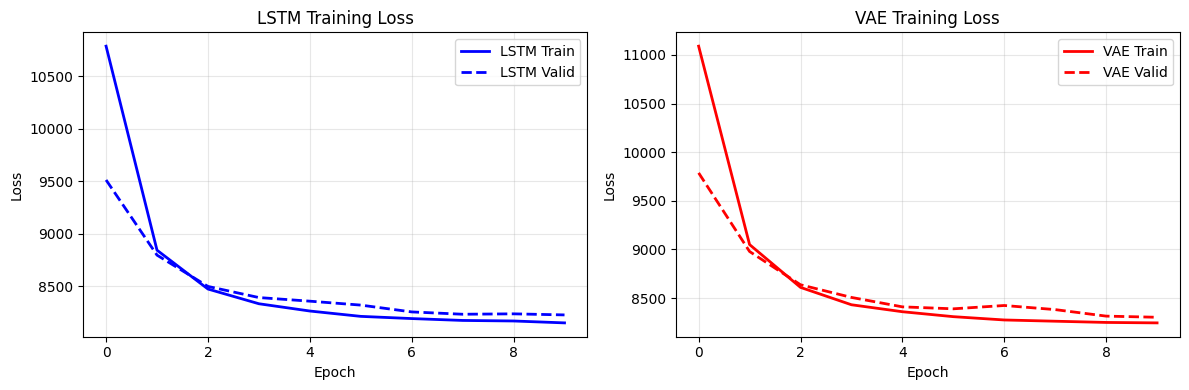


========== 生成詳細預測比較圖 ==========


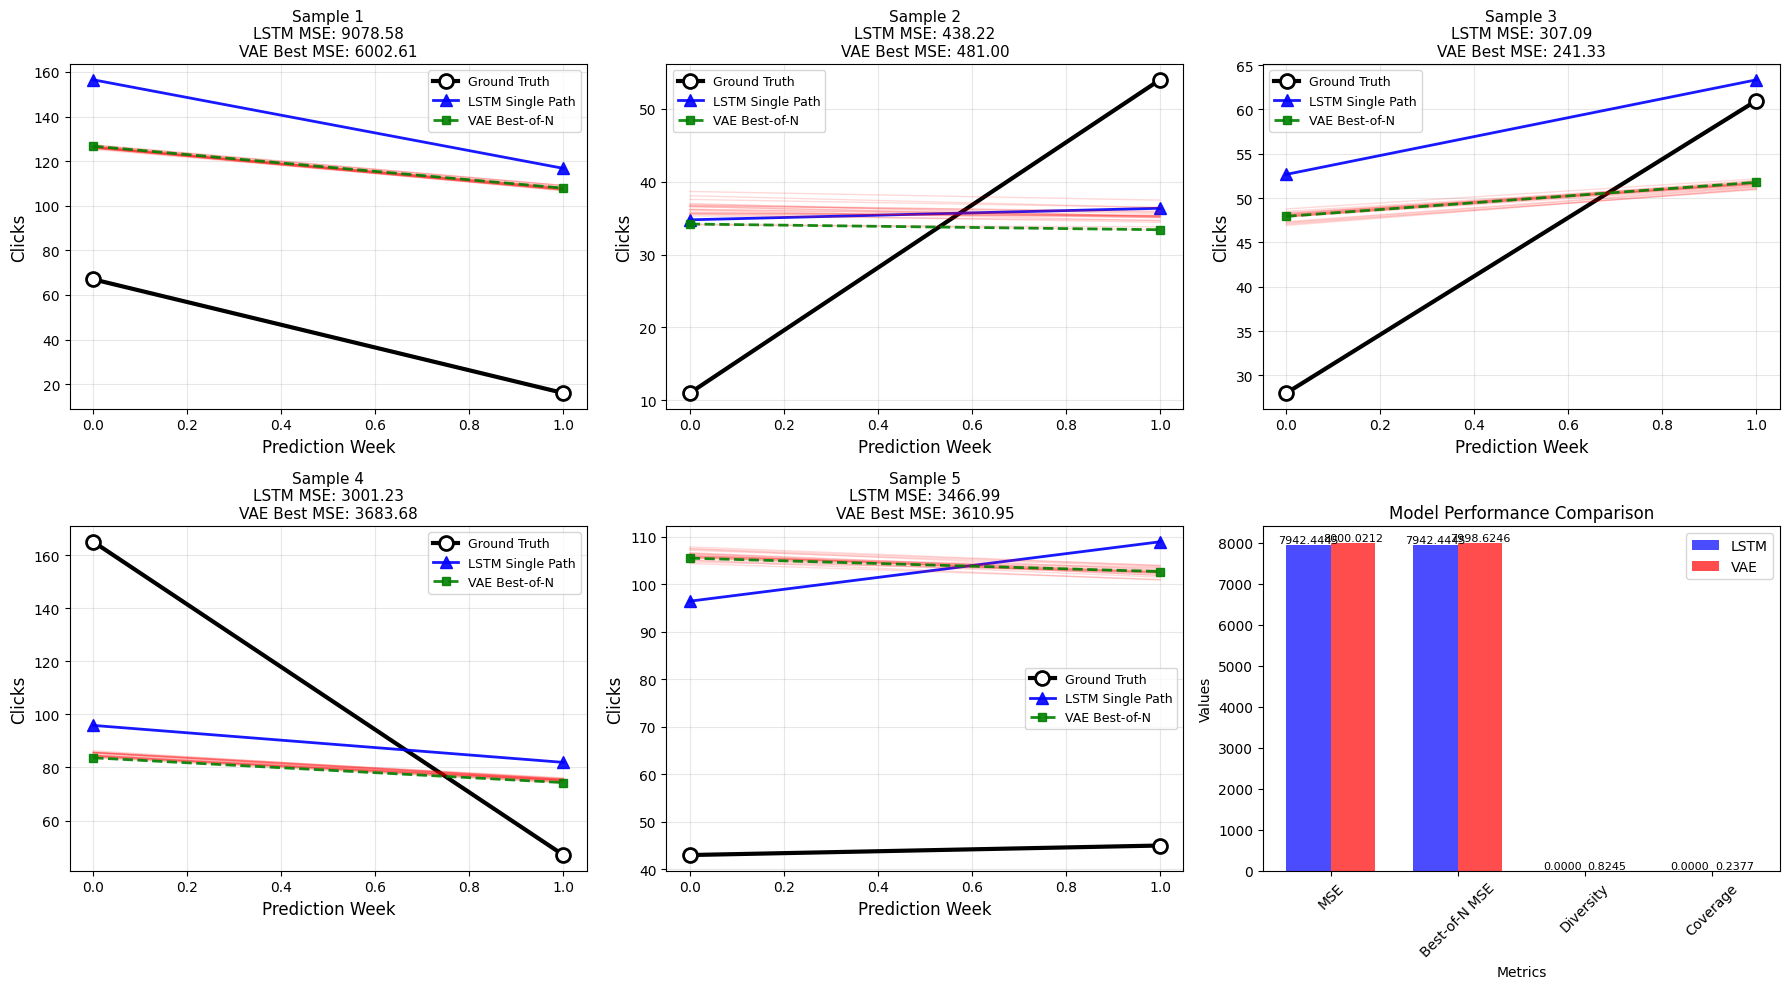


========== 生成單一樣本詳細分析 ==========


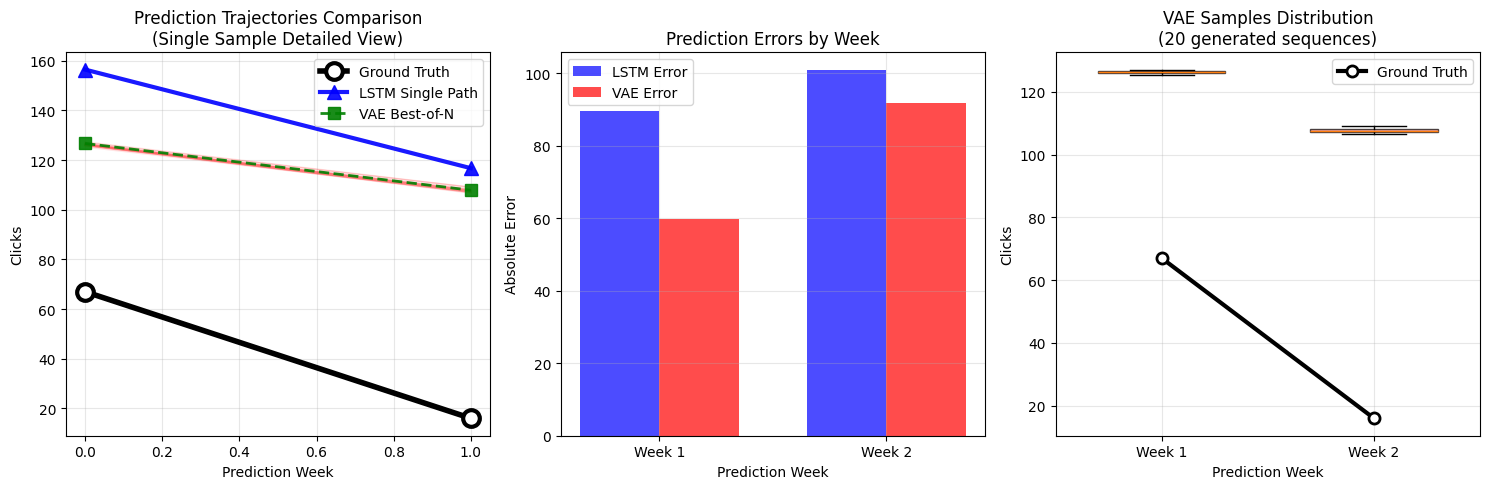

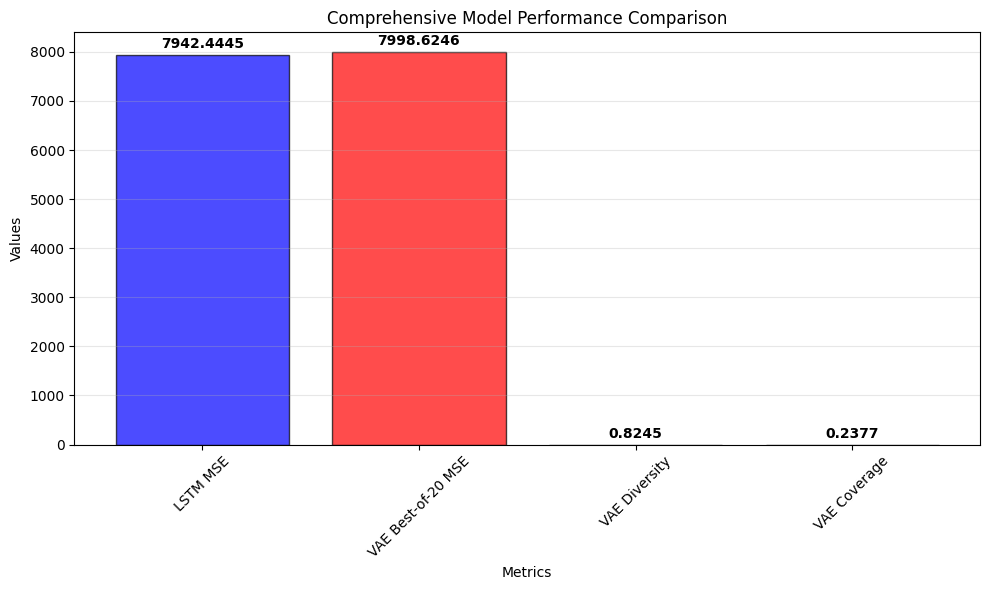


                     模型性能總結報告                     

📊 數值比較結果:
   • LSTM 單一路徑 MSE: 7942.4445
   • VAE Best-of-20 MSE: 7998.6246
   • VAE Diversity (std): 0.8245
   • VAE Coverage (比例): 0.2377
   • 改進百分比: -0.71%

🎯 關鍵觀察:
   ⚠ VAE 在當前設定下未超越 LSTM

📈 生成樣本統計:
   • VAE 生成樣本數: 20 條序列
   • 測試樣本數: 70389 個序列
   • 輸入週數: 4 週
   • 預測週數: 2 週

💾 輸出文件:
   1. training_loss.png - 訓練損失曲線
   2. detailed_prediction_comparison.png - 詳細預測比較
   3. single_sample_analysis.png - 單一樣本詳細分析
   4. comprehensive_comparison.png - 綜合性能比較


數值結果已保存至: model_comparison_results.csv


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 設定隨機種子
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==================== 資料讀取與前處理 ====================
# 請修改路徑為您的 Google Drive 中的資料集位置
DATA_PATH = '/content/drive/MyDrive/colab/'  # 修改此路徑

studentInfo = pd.read_csv(DATA_PATH + 'studentInfo.csv')
studentVle = pd.read_csv(DATA_PATH + 'studentVle.csv')
studentAssessment = pd.read_csv(DATA_PATH + 'studentAssessment.csv')

print("資料載入完成")
print(f"studentInfo shape: {studentInfo.shape}")
print(f"studentVle shape: {studentVle.shape}")
print(f"studentAssessment shape: {studentAssessment.shape}")

# 合併資料
# 計算每週點擊數
studentVle['week'] = studentVle['date'] // 7
weekly_clicks = studentVle.groupby(['id_student', 'week'])['sum_click'].sum().reset_index()
weekly_clicks.columns = ['id_student', 'week', 'clicks']

# 計算每週作業提交與分數
studentAssessment_merged = studentAssessment.merge(
    studentInfo[['id_student', 'code_module', 'code_presentation']],
    on='id_student'
)
studentAssessment_merged['week'] = studentAssessment_merged['date_submitted'] // 7
weekly_submit = studentAssessment_merged.groupby(['id_student', 'week']).agg({
    'score': 'mean',
    'id_assessment': 'count'
}).reset_index()
weekly_submit.columns = ['id_student', 'week', 'avg_score', 'submit_cnt']

# 合併特徵
weekly_data = weekly_clicks.merge(weekly_submit, on=['id_student', 'week'], how='outer')
weekly_data = weekly_data.fillna(0)
weekly_data['has_submit'] = (weekly_data['submit_cnt'] > 0).astype(int)

# 計算累積平均分數
weekly_data = weekly_data.sort_values(['id_student', 'week'])
weekly_data['avg_score_sofar'] = weekly_data.groupby('id_student')['avg_score'].expanding().mean().reset_index(level=0, drop=True)
weekly_data['avg_score_sofar'] = weekly_data['avg_score_sofar'].fillna(0)

# 計算點擊數差分
weekly_data['clicks_diff1'] = weekly_data.groupby('id_student')['clicks'].diff().fillna(0)

print(f"\n處理後資料 shape: {weekly_data.shape}")

# ==================== 建立序列資料 ====================
INPUT_WEEKS = 4
OUTPUT_WEEKS = 2
FEATURES = ['clicks', 'has_submit', 'avg_score_sofar', 'clicks_diff1']

def create_sequences(data, input_weeks=4, output_weeks=2):
    sequences = []
    targets = []
    student_ids = []

    for student_id in data['id_student'].unique():
        student_data = data[data['id_student'] == student_id].sort_values('week')

        if len(student_data) < input_weeks + output_weeks:
            continue

        for i in range(len(student_data) - input_weeks - output_weeks + 1):
            input_seq = student_data.iloc[i:i+input_weeks][FEATURES].values
            target_seq = student_data.iloc[i+input_weeks:i+input_weeks+output_weeks]['clicks'].values

            sequences.append(input_seq)
            targets.append(target_seq)
            student_ids.append(student_id)

    return np.array(sequences), np.array(targets), np.array(student_ids)

X, y, student_ids = create_sequences(weekly_data, INPUT_WEEKS, OUTPUT_WEEKS)
print(f"\n序列數據 shape: X={X.shape}, y={y.shape}")

# 以學生 ID 分割資料
unique_students = np.unique(student_ids)
train_students, temp_students = train_test_split(unique_students, test_size=0.3, random_state=SEED)
valid_students, test_students = train_test_split(temp_students, test_size=0.5, random_state=SEED)

train_mask = np.isin(student_ids, train_students)
valid_mask = np.isin(student_ids, valid_students)
test_mask = np.isin(student_ids, test_students)

X_train, y_train = X[train_mask], y[train_mask]
X_valid, y_valid = X[valid_mask], y[valid_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train: {len(X_train)}, Valid: {len(X_valid)}, Test: {len(X_test)}")

# ==================== Dataset ====================
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SequenceDataset(X_train, y_train)
valid_dataset = SequenceDataset(X_valid, y_valid)
test_dataset = SequenceDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ==================== Seq2Seq LSTM 模型 ====================
class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_weeks):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(1, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.output_weeks = output_weeks

    def forward(self, x):
        _, (h, c) = self.encoder(x)

        decoder_input = torch.zeros(x.size(0), self.output_weeks, 1).to(x.device)
        decoder_output, _ = self.decoder(decoder_input, (h, c))

        output = self.fc(decoder_output).squeeze(-1)
        return output

# ==================== Seq2Seq VAE 模型 ====================
class Seq2SeqVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, output_weeks):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.output_weeks = output_weeks

        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc_z = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(1, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, 1)

    def encode(self, x):
        _, (h, _) = self.encoder(x)
        h = h.squeeze(0)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_z(z).unsqueeze(0)
        c = torch.zeros_like(h)

        decoder_input = torch.zeros(z.size(0), self.output_weeks, 1).to(z.device)
        decoder_output, _ = self.decoder(decoder_input, (h, c))

        output = self.fc_out(decoder_output).squeeze(-1)
        return output

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

# ==================== 訓練函數 ====================
def train_lstm(model, train_loader, valid_loader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                valid_loss += loss.item()

        valid_loss /= len(valid_loader)
        valid_losses.append(valid_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")

    return train_losses, valid_losses

def train_vae(model, train_loader, valid_loader, epochs=10, beta=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    mse_criterion = nn.MSELoss()

    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            recon, mu, logvar = model(X_batch)

            recon_loss = mse_criterion(recon, y_batch)
            kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / X_batch.size(0)
            loss = recon_loss + beta * kld_loss

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                recon, mu, logvar = model(X_batch)

                recon_loss = mse_criterion(recon, y_batch)
                kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / X_batch.size(0)
                loss = recon_loss + beta * kld_loss

                valid_loss += loss.item()

        valid_loss /= len(valid_loader)
        valid_losses.append(valid_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")

    return train_losses, valid_losses

# ==================== 訓練模型 ====================
print("\n========== 訓練 Seq2Seq LSTM ==========")
lstm_model = Seq2SeqLSTM(input_dim=len(FEATURES), hidden_dim=64, output_weeks=OUTPUT_WEEKS).to(device)
lstm_train_losses, lstm_valid_losses = train_lstm(lstm_model, train_loader, valid_loader, epochs=10)

print("\n========== 訓練 Seq2Seq VAE ==========")
vae_model = Seq2SeqVAE(input_dim=len(FEATURES), hidden_dim=64, latent_dim=16, output_weeks=OUTPUT_WEEKS).to(device)
vae_train_losses, vae_valid_losses = train_vae(vae_model, train_loader, valid_loader, epochs=10, beta=0.1)

# ==================== 評估與可視化 ====================
def evaluate_lstm(model, X_test, y_test):
    """LSTM：輸出單一路徑預測"""
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_test).to(device)
        predictions = model(X_tensor).cpu().numpy()

    mse = np.mean((predictions - y_test) ** 2)
    return predictions, mse

def evaluate_vae(model, X_test, y_test, n_samples=20):
    """VAE：生成 N 條序列樣本"""
    model.eval()
    all_samples = []

    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_test).to(device)

        for _ in range(n_samples):
            mu, logvar = model.encode(X_tensor)
            z = model.reparameterize(mu, logvar)
            sample = model.decode(z).cpu().numpy()
            all_samples.append(sample)

    all_samples = np.array(all_samples)  # shape: (n_samples, n_sequences, output_weeks)

    # Best-of-N MSE: 選擇所有樣本中MSE最小的
    mse_per_sample = np.array([np.mean((sample - y_test) ** 2) for sample in all_samples])
    best_sample_idx = np.argmin(mse_per_sample)
    best_mse = mse_per_sample[best_sample_idx]
    best_predictions = all_samples[best_sample_idx]

    # Diversity: 計算所有樣本在每個時間點的標準差
    diversity = np.mean(np.std(all_samples, axis=0))

    # Coverage: 計算真實值是否落在預測樣本的某個範圍內
    threshold = np.median(np.std(y_test, axis=1)) * 0.5
    coverage = np.mean([
        np.any(np.abs(all_samples[:, i, :] - y_test[i]) < threshold)
        for i in range(len(y_test))
    ])

    return all_samples, best_predictions, best_mse, diversity, coverage

# 評估模型
print("\n========== 模型評估 ==========")
print("LSTM：生成單一路徑預測...")
lstm_pred, lstm_mse = evaluate_lstm(lstm_model, X_test, y_test)

print("VAE：生成 20 條序列樣本...")
vae_samples, vae_best_pred, vae_best_mse, vae_diversity, vae_coverage = evaluate_vae(vae_model, X_test, y_test, n_samples=20)

# ==================== 數值比較 ====================
print(f"\n========== 數值比較結果 ==========")
print(f"LSTM 單一路徑 MSE: {lstm_mse:.4f}")
print(f"VAE Best-of-20 MSE: {vae_best_mse:.4f}")
print(f"VAE Diversity (std): {vae_diversity:.4f}")
print(f"VAE Coverage (比例): {vae_coverage:.4f}")

# 計算改進百分比
improvement_percent = ((lstm_mse - vae_best_mse) / lstm_mse) * 100
print(f"VAE 相對於 LSTM 的改進: {improvement_percent:+.2f}%")

# ==================== 可視化 ====================
# 圖1: 訓練損失曲線
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(lstm_train_losses, 'b-', label='LSTM Train', linewidth=2)
plt.plot(lstm_valid_losses, 'b--', label='LSTM Valid', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(vae_train_losses, 'r-', label='VAE Train', linewidth=2)
plt.plot(vae_valid_losses, 'r--', label='VAE Valid', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# 圖2: 詳細預測比較 (5個樣本)
print("\n========== 生成詳細預測比較圖 ==========")
sample_indices = np.random.choice(len(X_test), 5, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, sample_idx in enumerate(sample_indices[:6]):  # 顯示6個樣本
    ax = axes[idx]

    # Ground Truth（真實未來 clicks）
    weeks = range(OUTPUT_WEEKS)
    ax.plot(weeks, y_test[sample_idx], 'ko-', label='Ground Truth',
            linewidth=3, markersize=10, markerfacecolor='white', markeredgewidth=2)

    # LSTM 單一路徑
    ax.plot(weeks, lstm_pred[sample_idx], 'b^-', label='LSTM Single Path',
            linewidth=2, markersize=8, alpha=0.9)

    # VAE 多條樣本（半透明曲線）
    for i in range(vae_samples.shape[0]):
        ax.plot(weeks, vae_samples[i, sample_idx], 'r-', alpha=0.15, linewidth=1)

    # VAE Best-of-N
    ax.plot(weeks, vae_best_pred[sample_idx], 'gs--', label='VAE Best-of-N',
            linewidth=2, markersize=6, alpha=0.9)

    ax.set_xlabel('Prediction Week', fontsize=12)
    ax.set_ylabel('Clicks', fontsize=12)
    ax.set_title(f'Sample {idx+1}\nLSTM MSE: {np.mean((lstm_pred[sample_idx] - y_test[sample_idx])**2):.2f}\n'
                f'VAE Best MSE: {np.mean((vae_best_pred[sample_idx] - y_test[sample_idx])**2):.2f}',
                fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# 最後一個子圖顯示數值比較
ax = axes[5]
metrics = ['MSE', 'Best-of-N MSE', 'Diversity', 'Coverage']
lstm_values = [lstm_mse, lstm_mse, 0, 0]
vae_values = [np.mean([np.mean((sample - y_test) ** 2) for sample in vae_samples]),
              vae_best_mse, vae_diversity, vae_coverage]

x_pos = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x_pos - width/2, lstm_values, width, label='LSTM', color='blue', alpha=0.7)
bars2 = ax.bar(x_pos + width/2, vae_values, width, label='VAE', color='red', alpha=0.7)

ax.set_xlabel('Metrics')
ax.set_ylabel('Values')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, rotation=45)
ax.legend()

# 添加數值標籤
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('detailed_prediction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 圖3: 單一樣本的詳細比較
print("\n========== 生成單一樣本詳細分析 ==========")
detailed_sample_idx = sample_indices[0]

plt.figure(figsize=(15, 5))

# 子圖1: 預測軌跡比較
plt.subplot(1, 3, 1)
weeks = range(OUTPUT_WEEKS)

# Ground Truth
plt.plot(weeks, y_test[detailed_sample_idx], 'ko-', label='Ground Truth',
         linewidth=4, markersize=12, markerfacecolor='white', markeredgewidth=3)

# LSTM 單一路徑
plt.plot(weeks, lstm_pred[detailed_sample_idx], 'b^-', label='LSTM Single Path',
         linewidth=3, markersize=10, alpha=0.9)

# VAE 多條樣本
for i in range(vae_samples.shape[0]):
    plt.plot(weeks, vae_samples[i, detailed_sample_idx], 'r-', alpha=0.1, linewidth=1)

# VAE Best-of-N
plt.plot(weeks, vae_best_pred[detailed_sample_idx], 'gs--', label='VAE Best-of-N',
         linewidth=2, markersize=8, alpha=0.9)

plt.xlabel('Prediction Week')
plt.ylabel('Clicks')
plt.title('Prediction Trajectories Comparison\n(Single Sample Detailed View)')
plt.legend()
plt.grid(True, alpha=0.3)

# 子圖2: 誤差分佈
plt.subplot(1, 3, 2)
lstm_errors = np.abs(lstm_pred[detailed_sample_idx] - y_test[detailed_sample_idx])
vae_errors = np.abs(vae_best_pred[detailed_sample_idx] - y_test[detailed_sample_idx])

x_pos = np.arange(OUTPUT_WEEKS)
width = 0.35

plt.bar(x_pos - width/2, lstm_errors, width, label='LSTM Error', color='blue', alpha=0.7)
plt.bar(x_pos + width/2, vae_errors, width, label='VAE Error', color='red', alpha=0.7)

plt.xlabel('Prediction Week')
plt.ylabel('Absolute Error')
plt.title('Prediction Errors by Week')
plt.xticks(x_pos, [f'Week {i+1}' for i in range(OUTPUT_WEEKS)])
plt.legend()
plt.grid(True, alpha=0.3)

# 子圖3: VAE 樣本分佈
plt.subplot(1, 3, 3)
vae_sample_values = vae_samples[:, detailed_sample_idx, :]

# 繪製箱形圖顯示VAE樣本的分佈
box_data = [vae_sample_values[:, i] for i in range(OUTPUT_WEEKS)]
box_plot = plt.boxplot(box_data, positions=range(OUTPUT_WEEKS), widths=0.6,
                       patch_artist=True, showfliers=False)

# 設置箱形圖顏色
for patch in box_plot['boxes']:
    patch.set_facecolor('lightcoral')
    patch.set_alpha(0.7)

# 添加真實值
plt.plot(range(OUTPUT_WEEKS), y_test[detailed_sample_idx], 'ko-', label='Ground Truth',
         linewidth=3, markersize=8, markerfacecolor='white', markeredgewidth=2)

plt.xlabel('Prediction Week')
plt.ylabel('Clicks')
plt.title('VAE Samples Distribution\n(20 generated sequences)')
plt.xticks(range(OUTPUT_WEEKS), [f'Week {i+1}' for i in range(OUTPUT_WEEKS)])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('single_sample_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 圖4: 模型性能綜合比較
plt.figure(figsize=(10, 6))

metrics_comparison = {
    'LSTM MSE': lstm_mse,
    'VAE Best-of-20 MSE': vae_best_mse,
    'VAE Diversity': vae_diversity,
    'VAE Coverage': vae_coverage
}

colors = ['blue', 'red', 'green', 'orange']
plt.bar(range(len(metrics_comparison)), list(metrics_comparison.values()),
        color=colors, alpha=0.7, edgecolor='black')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Comprehensive Model Performance Comparison')
plt.xticks(range(len(metrics_comparison)), list(metrics_comparison.keys()), rotation=45)
plt.grid(True, alpha=0.3, axis='y')

# 添加數值標籤
for i, (metric, value) in enumerate(metrics_comparison.items()):
    plt.text(i, value + max(metrics_comparison.values()) * 0.01, f'{value:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('comprehensive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 輸出總結報告 ====================
print(f"\n{'='*50}")
print(f"{'模型性能總結報告':^50}")
print(f"{'='*50}")

print(f"\n📊 數值比較結果:")
print(f"   • LSTM 單一路徑 MSE: {lstm_mse:.4f}")
print(f"   • VAE Best-of-20 MSE: {vae_best_mse:.4f}")
print(f"   • VAE Diversity (std): {vae_diversity:.4f}")
print(f"   • VAE Coverage (比例): {vae_coverage:.4f}")
print(f"   • 改進百分比: {improvement_percent:+.2f}%")

print(f"\n🎯 關鍵觀察:")
if improvement_percent > 0:
    print(f"   ✓ VAE Best-of-20 表現優於 LSTM 單一路徑")
    print(f"   ✓ 多樣性生成有助於找到更好的預測")
else:
    print(f"   ⚠ VAE 在當前設定下未超越 LSTM")

print(f"\n📈 生成樣本統計:")
print(f"   • VAE 生成樣本數: 20 條序列")
print(f"   • 測試樣本數: {len(X_test)} 個序列")
print(f"   • 輸入週數: {INPUT_WEEKS} 週")
print(f"   • 預測週數: {OUTPUT_WEEKS} 週")

print(f"\n💾 輸出文件:")
print(f"   1. training_loss.png - 訓練損失曲線")
print(f"   2. detailed_prediction_comparison.png - 詳細預測比較")
print(f"   3. single_sample_analysis.png - 單一樣本詳細分析")
print(f"   4. comprehensive_comparison.png - 綜合性能比較")

print(f"\n{'='*50}")

# 保存數值結果到文件
results_df = pd.DataFrame({
    'Model': ['LSTM', 'VAE Best-of-20', 'VAE Diversity', 'VAE Coverage'],
    'Value': [lstm_mse, vae_best_mse, vae_diversity, vae_coverage],
    'Description': [
        'Single path prediction MSE',
        'Best of 20 generated sequences MSE',
        'Standard deviation of generated sequences',
        'Proportion of true values covered by predictions'
    ]
})

results_df.to_csv('model_comparison_results.csv', index=False)
print(f"\n數值結果已保存至: model_comparison_results.csv")